# 最小限のVoxel Grid変換と分析

- Voxel Grid変換
- 変換結果の可視化
- 重心計算と軌跡
- 変化率のプロット

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from metavision_core.event_io import EventsIterator
import os
import math

## 設定

In [56]:
HEIGHT = 320
WIDTH = 320
NUM_BINS = 10
DATA_DIR = "data"

## 関数定義

In [57]:
def load_events(filepath, start_time_s=None, duration_s=None):
    """
    HDF5からイベントを読み込み
    
    Parameters
    ----------
    start_time_s : float, optional
        開始時刻（秒）。ファイルの先頭からの秒数
    duration_s : float, optional
        継続時間（秒）。start_time_sからの秒間を取得
    """
    events_list = []
    it = EventsIterator(filepath, delta_t=100_000)
    for ev in it:
        if len(ev) > 0:
            events_list.append(ev.copy())
    
    events = np.concatenate(events_list) if events_list else np.array([])
    
    if len(events) == 0:
        return events
    
    t0_global = events['t'][0]  # ファイルの絶対的な開始時刻
    
    # 開始時刻を指定
    if start_time_s is not None:
        t_start = t0_global + int(start_time_s * 1e6)
        events = events[events['t'] >= t_start]
    
    # 継続時間を指定（開始時刻の後ろから何秒間か）
    if duration_s is not None and len(events) > 0:
        t0_actual = events['t'][0]  # 実際の開始時刻
        t_end = t0_actual + int(duration_s * 1e6)
        events = events[events['t'] <= t_end]
    
    return events

In [48]:
def events_to_voxel_grid(events, num_bins=NUM_BINS, 
                         height=HEIGHT, width=WIDTH):
    """
    イベントをVoxel Gridに変換
    式(1)-(3): bilinear temporal interpolation
    
    Returns
    -------
    voxel : ndarray (B, H, W)
        Voxel Grid
    """
    voxel = np.zeros((num_bins, height, width), dtype=np.float32)
    
    if len(events) == 0:
        return voxel
    
    t0 = float(events['t'][0])
    tN = float(events['t'][-1])
    
    if t0 == tN:
        return voxel
    
    # 正規化タイムスタンプ
    t_star = (num_bins - 1) * (events['t'].astype(np.float64) - t0) / (tN - t0)
    polarity = events['p'].astype(np.float32) * 2.0 - 1.0
    
    # Bilinear kernel (式2-3)
    for b in range(num_bins):
        weight_t = np.maximum(0.0, 1.0 - np.abs(b - t_star)).astype(np.float32)
        mask = weight_t > 0
        if not np.any(mask):
            continue
        np.add.at(voxel[b],
                  (events['y'][mask].astype(np.int32),
                   events['x'][mask].astype(np.int32)),
                  (polarity * weight_t)[mask])
    
    return voxel

In [49]:
def compute_diff_voxels(events, num_bins=NUM_BINS,
                        height=HEIGHT, width=WIDTH):
    """
    ビン間差分Voxelを計算
    ΔV[b] = V[b+1] - V[b]
    
    Returns
    -------
    full_voxel : ndarray (B, H, W)
    diff_voxels : ndarray (B-1, H, W)
    """
    full_voxel = events_to_voxel_grid(events, num_bins, height, width)
    diff_voxels = np.diff(full_voxel, axis=0)
    
    return full_voxel, diff_voxels

In [50]:
def compute_centroid_trajectories(diff_voxels):
    """
    各差分Voxelの重心（Y, X座標）を計算
    
    Returns
    -------
    cy_seq : list[float]
        各差分ステップの重心Y座標（正規化）
    cx_seq : list[float]
        各差分ステップの重心X座標（正規化）
    """
    n_diffs = diff_voxels.shape[0]
    height, width = diff_voxels.shape[1], diff_voxels.shape[2]
    
    ys_coord = np.arange(height, dtype=np.float32)[:, None]
    xs_coord = np.arange(width, dtype=np.float32)[None, :]
    
    cy_seq = []
    cx_seq = []
    
    for b in range(n_diffs):
        d = diff_voxels[b]
        d_abs = np.abs(d)
        tot = d_abs.sum() + 1e-9
        
        cy = float((d_abs * ys_coord).sum() / tot / height)
        cx = float((d_abs * xs_coord).sum() / tot / width)
        
        cy_seq.append(cy)
        cx_seq.append(cx)
    
    return cy_seq, cx_seq

## データ読み込み

In [51]:
print("イベントデータ読み込み中...")

# テストファイル（FALL_DOWN_1のみ）
label = "FALL_DOWN_1"
fname = "FALL_DOWN_1.hdf5"
path = os.path.join(DATA_DIR, fname)

# 開始時刻と継続時間を指定
START_TIME_S = 5.0   # 5秒時点から開始
DURATION_S = 2.0     # 2.0秒間を分析

ev = load_events(path, start_time_s=START_TIME_S, duration_s=DURATION_S)
all_events = {label: ev}

dur_s = (ev['t'][-1] - ev['t'][0]) / 1e6 if len(ev) > 0 else 0
print(f"  {label}: {len(ev):,} events, {dur_s:.1f}s")
print(f"    (開始: {START_TIME_S}秒, 継続時間: {DURATION_S}秒)")

イベントデータ読み込み中...
  FALL_DOWN_1: 1,823,399 events, 2.0s
    (開始: 5.0秒, 継続時間: 2.0秒)


## ビン間差分Voxelの可視化（4枚ごとに折り返し）

In [52]:
label = "FALL_DOWN_1"
ev = all_events[label]
full_v, diff_v = compute_diff_voxels(ev)
cy_seq, cx_seq = compute_centroid_trajectories(diff_v)
centroids_data = {label: (cy_seq, cx_seq)}

print(f"形状確認:")
print(f"  full_voxel: {full_v.shape}")
print(f"  diff_voxels: {diff_v.shape}")

形状確認:
  full_voxel: (10, 320, 320)
  diff_voxels: (9, 320, 320)


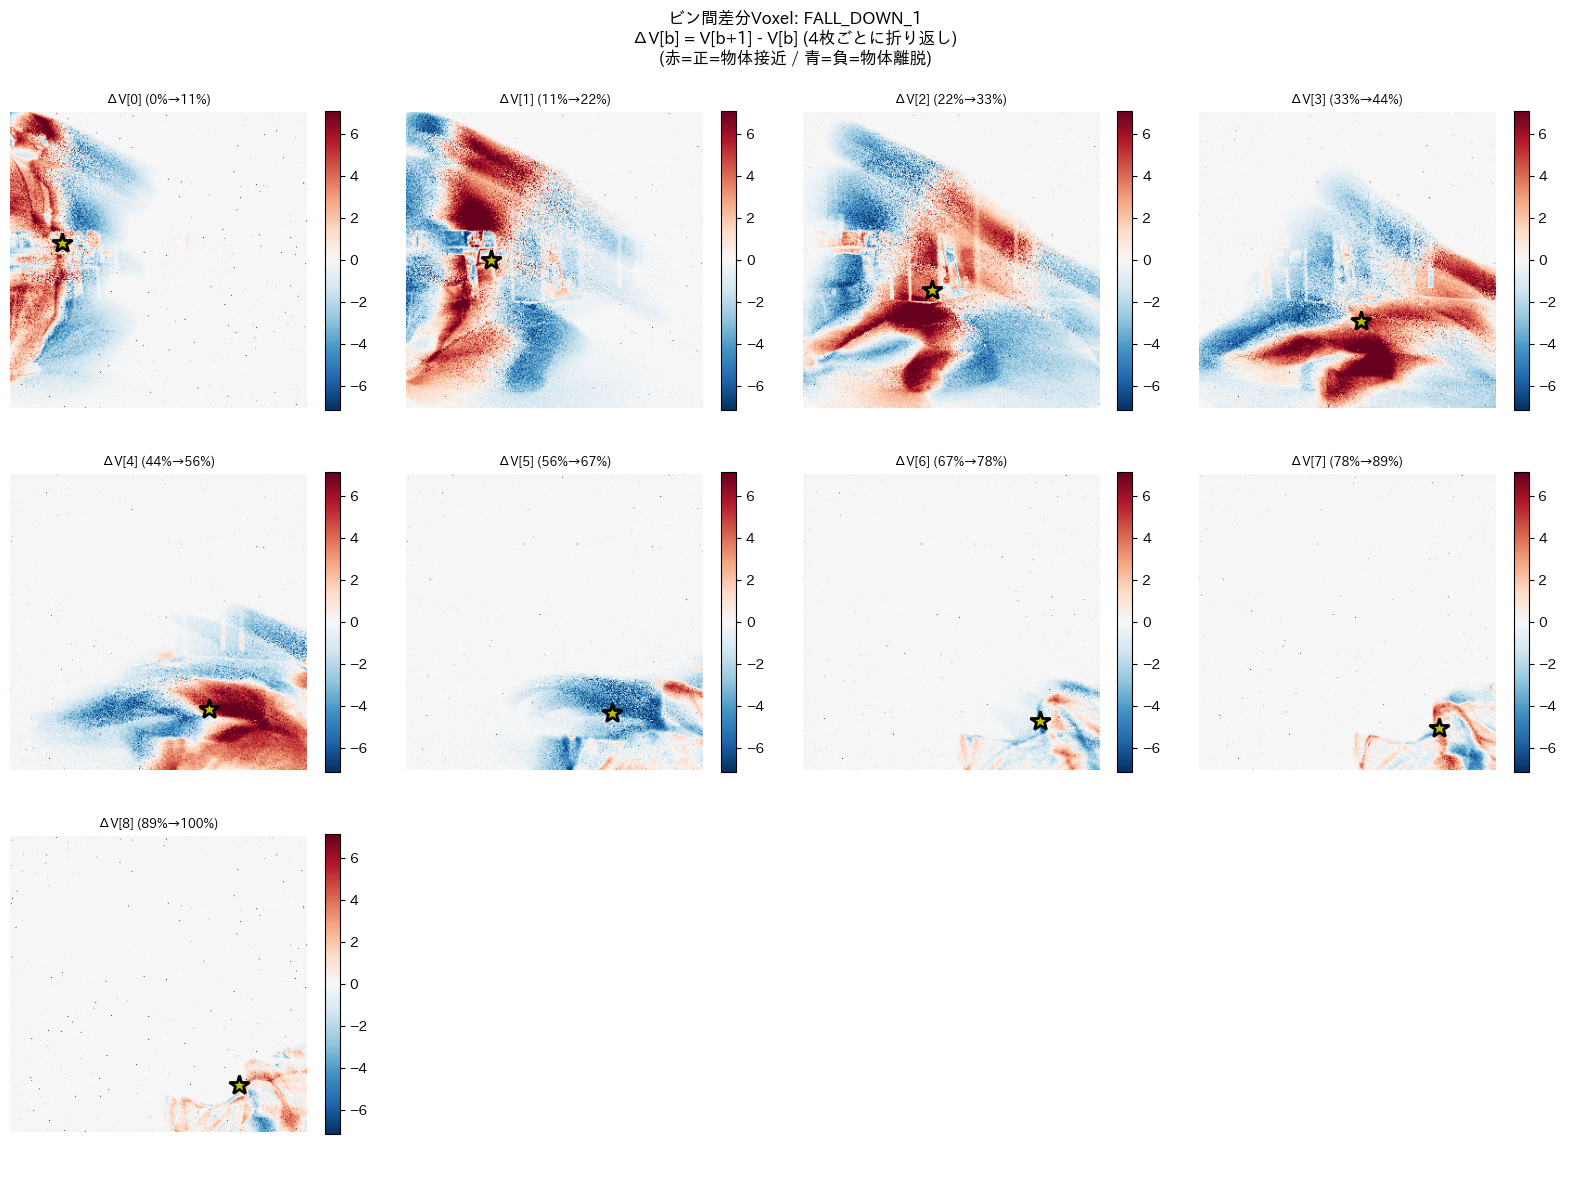

In [53]:
n_diffs = diff_v.shape[0]
COLS_PER_ROW = 4
rows_per_file = math.ceil(n_diffs / COLS_PER_ROW)

fig, axes = plt.subplots(rows_per_file, COLS_PER_ROW, 
                         figsize=(16, rows_per_file * 4))
# 常に2D配列として扱う
if rows_per_file == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    f"ビン間差分Voxel: {label}\n"
    "ΔV[b] = V[b+1] - V[b] (4枚ごとに折り返し)\n"
    "(赤=正=物体接近 / 青=負=物体離脱)",
    fontsize=12, fontweight="bold"
)

vmax = np.percentile(np.abs(diff_v), 99) + 1e-9

for b in range(n_diffs):
    local_row = b // COLS_PER_ROW
    local_col = b % COLS_PER_ROW
    
    ax = axes[local_row, local_col]
    
    # 差分Voxel表示
    im = ax.imshow(diff_v[b], cmap='RdBu_r',
                  vmin=-vmax, vmax=vmax,
                  origin='upper', aspect='equal')
    
    # 重心を黄色の星でプロット
    cy = cy_seq[b]
    cx = cx_seq[b]
    ax.plot(cx * WIDTH, cy * HEIGHT, 'y*', 
           markersize=15, markeredgewidth=2, 
           markeredgecolor='black')
    
    t_start = f"{b * 100 / n_diffs:.0f}%"
    t_end = f"{(b+1) * 100 / n_diffs:.0f}%"
    ax.set_title(f"ΔV[{b}] ({t_start}→{t_end})", fontsize=9)
    ax.axis('off')
    
    plt.colorbar(im, ax=ax, shrink=0.8)

# 未使用セルを非表示
for b in range(n_diffs, rows_per_file * COLS_PER_ROW):
    local_row = b // COLS_PER_ROW
    local_col = b % COLS_PER_ROW
    axes[local_row, local_col].axis('off')

plt.tight_layout()
plt.show()

## 重心軌跡と変化率のプロット

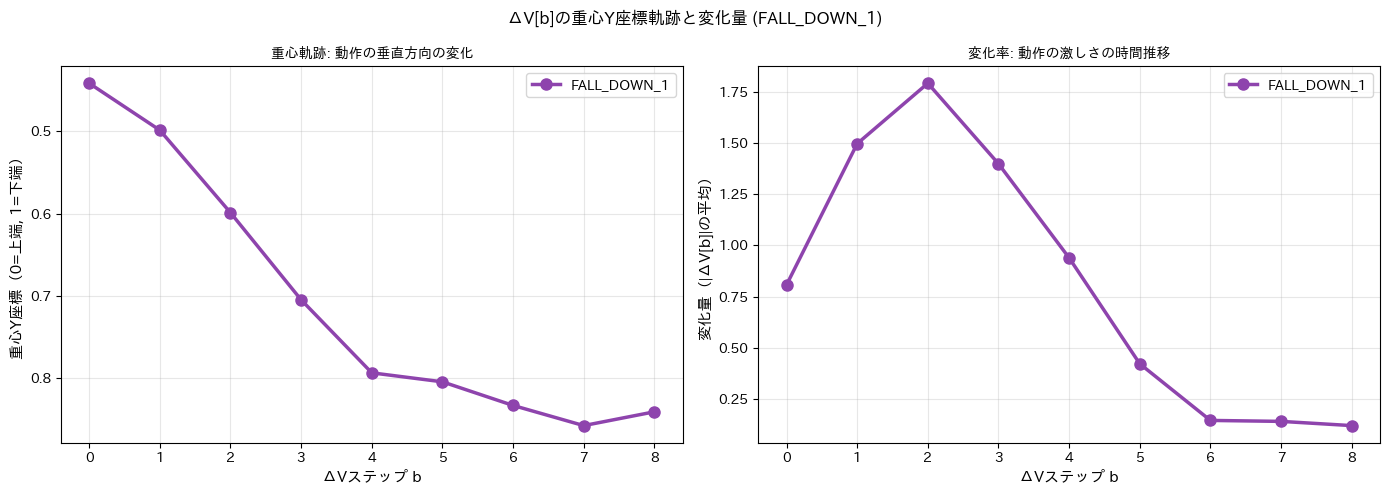

In [54]:
fig, (ax_cy, ax_mag) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"ΔV[b]の重心Y座標軌跡と変化量 ({label})",
    fontsize=12, fontweight="bold"
)

cy_seq, cx_seq = centroids_data[label]
n_diffs = len(cy_seq)
x_idx = np.arange(n_diffs)
color = '#8E44AD'  # FALL_DOWN用の紫色

# 重心Y軌跡
ax_cy.plot(x_idx, cy_seq, 'o-', color=color,
          linewidth=2.5, markersize=8, label=label)

# 変化量（ビン間差分の絶対値平均）
mag_seq = [np.abs(diff_v[b]).mean() for b in range(n_diffs)]
ax_mag.plot(x_idx, mag_seq, 'o-', color=color,
           linewidth=2.5, markersize=8, label=label)

# Y軸ラベル
ax_cy.set_xlabel("ΔVステップ b", fontsize=11)
ax_cy.set_ylabel("重心Y座標（0=上端, 1=下端）", fontsize=11)
ax_cy.set_title("重心軌跡: 動作の垂直方向の変化", fontsize=10)
ax_cy.invert_yaxis()
ax_cy.legend(fontsize=10)
ax_cy.grid(alpha=0.3)

# 変化量
ax_mag.set_xlabel("ΔVステップ b", fontsize=11)
ax_mag.set_ylabel("変化量（|ΔV[b]|の平均）", fontsize=11)
ax_mag.set_title("変化率: 動作の激しさの時間推移", fontsize=10)
ax_mag.legend(fontsize=10)
ax_mag.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 統計出力

In [55]:
print("="*60)
print("重心軌跡統計")
print("="*60)

label_key = "FALL_DOWN_1"
cy_seq, cx_seq = centroids_data[label_key]
cy_change = cy_seq[-1] - cy_seq[0]
cy_range = max(cy_seq) - min(cy_seq)

print(f"\n{label_key}:")
print(f"  重心Y変化 (終-始): {cy_change:+.4f}")
print(f"    (負=上昇, 正=下降)")
print(f"  重心Y移動幅: {cy_range:.4f}")
print(f"  開始Y座標: {cy_seq[0]:.4f}")
print(f"  終了Y座標: {cy_seq[-1]:.4f}")

print("\n✓ 分析完了")

重心軌跡統計

FALL_DOWN_1:
  重心Y変化 (終-始): +0.3992
    (負=上昇, 正=下降)
  重心Y移動幅: 0.4159
  開始Y座標: 0.4415
  終了Y座標: 0.8407

✓ 分析完了
